# 0.0 - Imports

In [233]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from xgboost import XGBRegressor

# 0.1 - Helper Functions

## 0.1.2 - Path

In [234]:
# Data file path constants
DATA_DIR = "./data"
CUSTOMERS_FILE = "../data/olist_customers_dataset.csv"
GEOLOCATION_FILE = "../data/olist_geolocation_dataset.csv"
ORDER_ITEMS_FILE = "../data/olist_order_items_dataset.csv"
ORDER_PAYMENTS_FILE = "../data/olist_order_payments_dataset.csv"
ORDER_REVIEWS_FILE = "../data/olist_order_reviews_dataset.csv"
ORDERS_FILE = "../data/olist_orders_dataset.csv"
PRODUCTS_FILE = "../data/olist_products_dataset.csv"
SELLERS_FILE = "../data/olist_sellers_dataset.csv"
PRODUCT_CATEGORY_TRANSLATION_FILE = (
    "../data/product_category_name_translation.csv"
)

# 0.2 - Load Data

In [235]:
# Load datasets
orders = pd.read_csv(ORDERS_FILE)
items = pd.read_csv(ORDER_ITEMS_FILE)
products = pd.read_csv(PRODUCTS_FILE)
reviews = pd.read_csv(ORDER_REVIEWS_FILE)

# Merge datasets
df_raw = orders.merge(items, on="order_id", how="left")
df_raw = df_raw.merge(products, on="product_id", how="left")
df_raw = df_raw.merge(reviews, on="order_id", how="left")

df_raw.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,500.0,19.0,8.0,13.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,400.0,19.0,13.0,19.0,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,420.0,24.0,19.0,21.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,450.0,30.0,10.0,20.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,250.0,51.0,15.0,15.0,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [236]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114092 non-null  object 
 1   customer_id                    114092 non-null  object 
 2   order_status                   114092 non-null  object 
 3   order_purchase_timestamp       114092 non-null  object 
 4   order_approved_at              113930 non-null  object 
 5   order_delivered_carrier_date   112112 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  114092 non-null  object 
 8   order_item_id                  113314 non-null  float64
 9   product_id                     113314 non-null  object 
 10  seller_id                      113314 non-null  object 
 11  shipping_limit_date            113314 non-null  object 
 12  price                         

# 1.0 - Format Data

In [237]:
df_feat = df_raw.copy()

In [238]:
# parse needed columns
df_feat["order_purchase_timestamp"] = pd.to_datetime(
    df_feat["order_purchase_timestamp"], errors="coerce"
)
for c in ["price", "freight_value", "review_score"]:
    df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")

df_feat = df_feat.dropna(subset=["order_purchase_timestamp", "order_id"])
df_feat = df_feat[df_feat["order_status"] == "delivered"].copy()

# week key (Monday start, stable with asfreq)
df_feat["week"] = (
    df_feat["order_purchase_timestamp"].dt.to_period("W-SUN").dt.start_time
)

weekly_base = (
    df_feat.groupby("week")
    .agg(sales_count=("order_id", "nunique"))
    .sort_index()
    .asfreq("W-MON")
)
weekly_base["sales_count"] = weekly_base["sales_count"].fillna(0)

# Remove last incomplete week
weekly_base = weekly_base.iloc[:-1].copy()

# keep full weekly target for split/backtest
weekly = weekly_base.copy()

# optional enriched features (separate object)
weekly_feat = (
    df_feat.groupby("week")
    .agg(
        sales_count=("order_id", "nunique"),
        active_sellers=("seller_id", "nunique"),
        active_customers=("customer_id", "nunique"),
        avg_price=("price", "mean"),
        avg_freight=("freight_value", "mean"),
        avg_review_score=("review_score", "mean"),
        revenue=("price", "sum"),
        items=("order_item_id", "count"),
    )
    .sort_index()
    .asfreq("W-MON")
)

# Remove last incomplete week from features too
weekly_feat = weekly_feat.iloc[:-1].copy()

weekly_feat["sales_count"] = weekly_feat["sales_count"].fillna(0)
for c in [
    "active_sellers",
    "active_customers",
    "avg_price",
    "avg_freight",
    "avg_review_score",
    "revenue",
    "items",
]:
    weekly_feat[c] = weekly_feat[c].interpolate()

weekly_feat["avg_items_per_order"] = weekly_feat["items"] / weekly_feat[
    "sales_count"
].replace(0, np.nan)
weekly_feat["avg_order_value"] = weekly_feat["revenue"] / weekly_feat[
    "sales_count"
].replace(0, np.nan)

# renamed month-based columns to week-based calendar columns
weekly_feat["week_of_year"] = weekly_feat.index.isocalendar().week.astype(int)
weekly_feat["year"] = weekly_feat.index.year
weekly_feat["is_black_friday_period"] = (
    (weekly_feat.index.month == 11) & (weekly_feat.index.day >= 20)
).astype(int)
weekly_feat["is_year_end_period"] = (weekly_feat.index.month == 12).astype(int)

for col in [
    "active_sellers",
    "active_customers",
    "avg_price",
    "avg_freight",
    "avg_review_score",
    "avg_order_value",
]:
    weekly_feat[f"{col}_lag1"] = weekly_feat[col].shift(1)

# target lags and rolling (weekly windows)
for l in [1, 2, 3, 4, 8, 12, 52]:
    weekly_feat[f"sales_lag_{l}"] = weekly_feat["sales_count"].shift(l)
weekly_feat["sales_roll4"] = (
    weekly_feat["sales_count"].shift(1).rolling(4).mean()
)
weekly_feat["sales_roll8"] = (
    weekly_feat["sales_count"].shift(1).rolling(8).mean()
)
weekly_feat["sales_roll12"] = (
    weekly_feat["sales_count"].shift(1).rolling(12).mean()
)

# this one is for ML with lags (can be smaller, that's OK)
weekly_ml = weekly_feat.dropna().copy()

print("weekly shape (target series):", weekly.shape)
print("weekly_ml shape (feature-ready):", weekly_ml.shape)
display(weekly.head())
display(weekly_ml.head())

weekly shape (target series): (102, 1)
weekly_ml shape (feature-ready): (50, 30)


,sales_count
week,
2016-09-12,1.0
2016-09-19,0.0
2016-09-26,0.0
2016-10-03,231.0
2016-10-10,34.0


,sales_count,active_sellers,active_customers,avg_price,avg_freight,avg_review_score,revenue,items,avg_items_per_order,avg_order_value,...,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_4,sales_lag_8,sales_lag_12,sales_lag_52,sales_roll4,sales_roll8,sales_roll12
week,,,,,,,,,,,,,,,,,,,,,
2017-09-11,1136.0,411.0,1136.0,121.703790,19.883214,4.082677,156389.37,1285.0,1.131162,137.666699,...,879.0,979.0,862.0,1008.0,937.0,635.0,1.0,932.0,927.875,873.666667
2017-09-18,956.0,346.0,956.0,111.939609,19.151584,4.234557,125820.12,1124.0,1.175732,131.611004,...,1136.0,879.0,979.0,862.0,893.0,706.0,0.0,964.0,952.750,915.416667
2017-09-25,925.0,362.0,925.0,131.824185,19.312706,4.198122,140788.23,1068.0,1.154595,152.203492,...,956.0,1136.0,879.0,979.0,954.0,794.0,0.0,987.5,960.625,936.250000
2017-10-02,975.0,394.0,975.0,125.865519,20.343061,4.032057,141850.44,1127.0,1.155897,145.487631,...,925.0,956.0,1136.0,879.0,911.0,926.0,231.0,974.0,957.000,947.166667
2017-10-09,1030.0,394.0,1030.0,126.396624,19.810111,4.127367,148263.24,1173.0,1.138835,143.944893,...,975.0,925.0,956.0,1136.0,1008.0,937.0,34.0,998.0,965.000,951.250000


# 2.0 - Split Data

In [239]:
# Train-test split for future model testing
# Last ~3 months reserved for test (12 weeks forecast horizon)
HORIZON = 12
train = weekly.iloc[:-HORIZON].copy()
test = weekly.iloc[-HORIZON:].copy()

print(
    f"Train period: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} weeks)"
)
print(
    f"Test period : {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} weeks)"
)

Train period: 2016-09-12 -> 2018-05-28  (90 weeks)
Test period : 2018-06-04 -> 2018-08-20  (12 weeks)


# 3.0 - Decompose Time Series

Apenas 102 semanas disponíveis. Usando period=13 (trimestral) como alternativa.


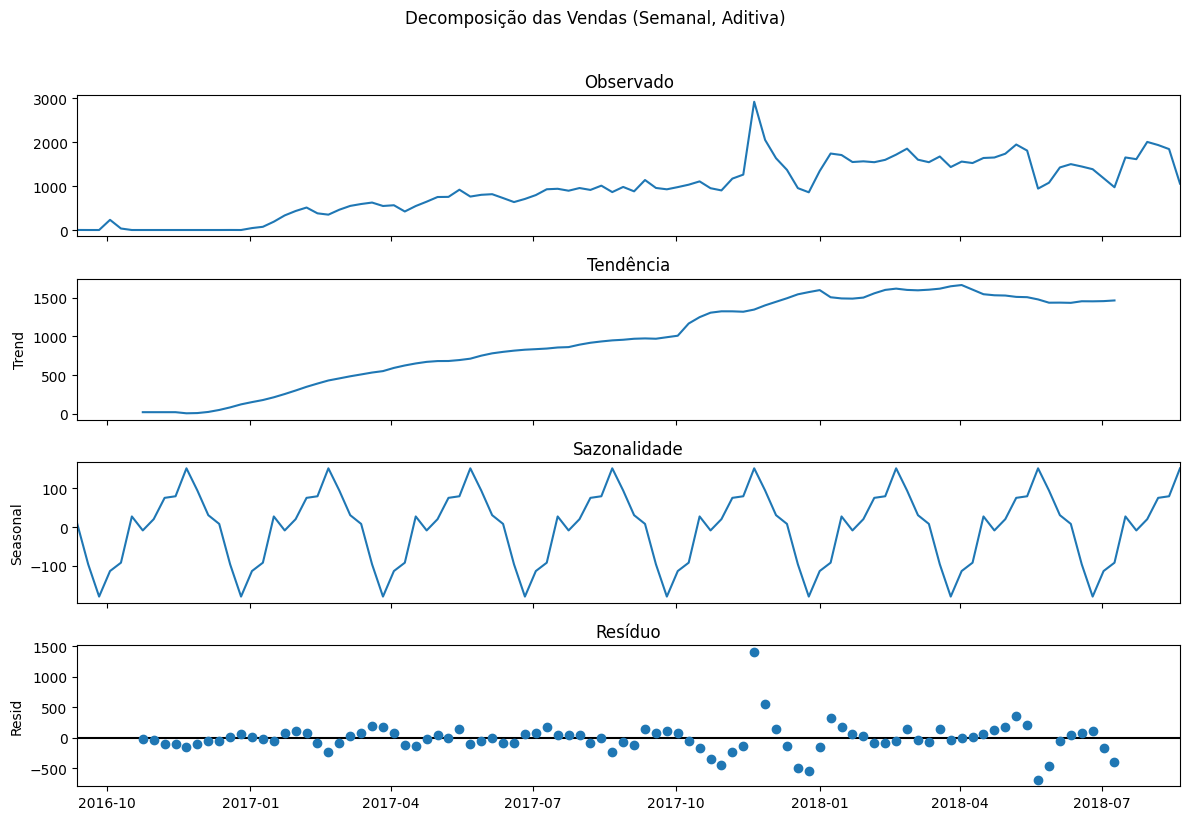

In [240]:
# Decomposição simples (clássica aditiva) em sales_count
if len(weekly) >= 104:  # ~2 anos para sazonalidade anual semanal
    decomp = seasonal_decompose(
        weekly["sales_count"], model="additive", period=52
    )
    print("Usando period=52 (sazonalidade anual)")
else:
    print(
        f"Apenas {len(weekly)} semanas disponíveis. Usando period=13 (trimestral) como alternativa."
    )
    decomp = seasonal_decompose(
        weekly["sales_count"], model="additive", period=13
    )

fig = decomp.plot()
fig.set_size_inches(12, 8)

# Traduz títulos dos subplots gerados automaticamente
axes = fig.get_axes()
pt_titles = ["Observado", "Tendência", "Sazonalidade", "Resíduo"]
for ax, t in zip(axes, pt_titles):
    ax.set_title(t)

fig.suptitle("Decomposição das Vendas (Semanal, Aditiva)", y=1.02)
plt.tight_layout()
plt.show()

# Series Interpretation

In [ ]:
# Quick interpretation of components
trend = decomp.trend.dropna()
trend_direction = (
    "crescente" if trend.iloc[-1] > trend.iloc[0] else "decrescente"
)

seasonal_strength = decomp.seasonal.abs().mean()
resid_strength = decomp.resid.dropna().abs().mean()

print("\nInterpretação da Série:")
print(f"- Tendência: {trend_direction} ao longo do tempo.")
print(
    f"- Sazonalidade: presente (média do efeito sazonal absoluto = {seasonal_strength:,.2f} vendas)."
)
print(
    f"- Nível de ruído residual (média do resíduo absoluto): {resid_strength:,.2f} vendas."
)
print(
    "- Se o ruído residual for alto em relação ao efeito sazonal, a previsão será mais difícil."
)


Interpretação da Série:
- Tendência: upward ao longo do tempo.
- Sazonalidade: presente (média do efeito sazonal absoluto = 75.49 vendas).
- Nível de ruído residual (média do resíduo absoluto): 147.16 vendas.
- Se o ruído residual for alto em relação ao efeito sazonal, a previsão será mais difícil.


# Train and Test Model

In [242]:
# Rolling backtest settings
def build_feature_frame(s: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({"y": s.astype(float).copy()})
    df["lag_1"] = df["y"].shift(1)
    df["lag_2"] = df["y"].shift(2)
    df["lag_3"] = df["y"].shift(3)
    df["lag_4"] = df["y"].shift(4)
    df["lag_8"] = df["y"].shift(8)
    df["lag_12"] = df["y"].shift(12)
    df["lag_26"] = df["y"].shift(26)
    df["lag_52"] = df["y"].shift(52)
    df["roll4_mean"] = df["y"].shift(1).rolling(4).mean()
    df["roll8_mean"] = df["y"].shift(1).rolling(8).mean()
    df["roll12_mean"] = df["y"].shift(1).rolling(12).mean()
    df["week_of_year"] = df.index.isocalendar().week.astype(int)
    df["t"] = np.arange(len(df))
    return df


series = weekly["sales_count"].astype(float).copy()
horizon = 12  # ~3-month forecast in weeks
seasonal_periods = 52  # weekly yearly seasonality

# Need enough history for lag_52 + rolling + seasonal model
min_train_size = 70
cutoffs = list(range(min_train_size, len(series) - horizon + 1))

print(f"Total weeks: {len(series)}")
print(f"Number of rolling folds: {len(cutoffs)}")

if len(cutoffs) == 0:
    raise ValueError(
        f"No rolling folds available. len(series)={len(series)}, "
        f"min_train_size={min_train_size}, horizon={horizon}. "
        f"Reduce min_train_size or horizon."
    )

rows = []

for split_idx in cutoffs:
    train_s = series.iloc[:split_idx].copy()
    test_s = series.iloc[split_idx : split_idx + horizon].copy()
    test_idx = test_s.index

    # 1) Naive last value (recursive multi-step)
    naive_preds = []
    hist_naive = train_s.copy()
    for dt in test_idx:
        yhat = hist_naive.iloc[-1]
        naive_preds.append(yhat)
        hist_naive = pd.concat([hist_naive, pd.Series([yhat], index=[dt])])

    naive_pred = pd.Series(naive_preds, index=test_idx)
    rows.append(
        {
            "fold_end_train": train_s.index[-1],
            "model": "NaiveLastValue",
            "rmse": np.sqrt(mean_squared_error(test_s, naive_pred)),
            "mae": mean_absolute_error(test_s, naive_pred),
        }
    )

    # 2) Exponential Smoothing (protected)
    try:
        es_model = ExponentialSmoothing(
            train_s,
            trend="add",
            damped_trend=True,
            seasonal="add",
            seasonal_periods=seasonal_periods,
            initialization_method="estimated",
        ).fit(optimized=True)

        es_pred = es_model.forecast(horizon).clip(lower=0)
        es_pred.index = test_idx

        rows.append(
            {
                "fold_end_train": train_s.index[-1],
                "model": "ExponentialSmoothing",
                "rmse": np.sqrt(mean_squared_error(test_s, es_pred)),
                "mae": mean_absolute_error(test_s, es_pred),
            }
        )
    except Exception:
        pass

    # 3) XGBoost (protected, recursive multi-step)
    try:
        feat_all = build_feature_frame(train_s).dropna().copy()
        if len(feat_all) > 0:
            X_train = feat_all.drop(columns=["y"])
            y_train = feat_all["y"]
            feature_cols = X_train.columns.tolist()

            xgb_model = XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="reg:squarederror",
                random_state=42,
            )
            xgb_model.fit(X_train, y_train)

            xgb_preds = []
            hist_xgb = train_s.copy()

            for dt in test_idx:
                x = {
                    "week_of_year": int(dt.isocalendar().week),
                    "t": len(hist_xgb),
                }
                for l in [1, 2, 3, 4, 8, 12, 26, 52]:
                    x[f"lag_{l}"] = hist_xgb.iloc[-l]
                x["roll4_mean"] = hist_xgb.iloc[-4:].mean()
                x["roll8_mean"] = hist_xgb.iloc[-8:].mean()
                x["roll12_mean"] = hist_xgb.iloc[-12:].mean()

                x_dt = pd.DataFrame([x], index=[dt]).reindex(
                    columns=feature_cols
                )
                yhat = max(0, xgb_model.predict(x_dt)[0])
                xgb_preds.append(yhat)
                hist_xgb = pd.concat([hist_xgb, pd.Series([yhat], index=[dt])])

            xgb_pred = pd.Series(xgb_preds, index=test_idx)

            rows.append(
                {
                    "fold_end_train": train_s.index[-1],
                    "model": "XGBoost",
                    "rmse": np.sqrt(mean_squared_error(test_s, xgb_pred)),
                    "mae": mean_absolute_error(test_s, xgb_pred),
                }
            )
    except Exception:
        pass

# Aggregate
backtest_df = pd.DataFrame(rows)

if backtest_df.empty or "model" not in backtest_df.columns:
    raise ValueError(
        "No model results were generated. Check data length and model errors."
    )

summary = (
    backtest_df.groupby("model", as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        n_folds=("rmse", "count"),
    )
    .sort_values("mean_rmse")
)

print()
print(summary)

Total weeks: 102
Number of rolling folds: 21



            model   mean_rmse    mean_mae  n_folds
1         XGBoost  277.873581  218.580509       21
0  NaiveLastValue  312.450379  256.170635       21


# Predict Next 12 Weeks

In [243]:
# Train final XGBoost model on full training data (before test split)
# build_feature_frame expects a Series, not a DataFrame
series_train = train["sales_count"].astype(float).copy()
feat_full = build_feature_frame(series_train).dropna().copy()
X_train_full = feat_full.drop(columns=["y"])
y_train_full = feat_full["y"]
feature_cols = X_train_full.columns.tolist()

xgb_final = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
)
xgb_final.fit(X_train_full, y_train_full)

# Predict next 12 weeks using the trained XGBoost model
forecast_horizon = 12
future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(weeks=1),
    periods=forecast_horizon,
    freq="W-MON",
)

# Build features and make predictions recursively
forecast_preds = []
hist_forecast = series.copy()

for dt in future_dates:
    x = {
        "week_of_year": int(dt.isocalendar().week),
        "t": len(hist_forecast),
    }
    for l in [1, 2, 3, 4, 8, 12, 26, 52]:
        x[f"lag_{l}"] = (
            hist_forecast.iloc[-l]
            if len(hist_forecast) >= l
            else hist_forecast.iloc[-1]
        )

    x["roll4_mean"] = hist_forecast.iloc[-4:].mean()
    x["roll8_mean"] = hist_forecast.iloc[-8:].mean()
    x["roll12_mean"] = hist_forecast.iloc[-12:].mean()

    x_df = pd.DataFrame([x], index=[dt]).reindex(columns=feature_cols)
    yhat = max(0, xgb_final.predict(x_df)[0])
    forecast_preds.append(yhat)
    hist_forecast = pd.concat([hist_forecast, pd.Series([yhat], index=[dt])])

forecast_series = pd.Series(
    forecast_preds, index=future_dates, name="sales_count"
)
# Combine historical data with forecast (keeping index as date)
forecast_df = forecast_series.to_frame(name="sales_count")
historical_labeled_df = weekly[["sales_count"]].copy()
historical_labeled_df["data_type"] = "historical"

forecast_labeled_df = forecast_df.copy()
forecast_labeled_df["data_type"] = "forecast"

combined_labeled_df = pd.concat(
    [historical_labeled_df, forecast_labeled_df], axis=0
).sort_index()

# Keep index and name it 'date'
combined_labeled_df.index.name = "date"

In [244]:
# Ensure output folder exists
output_dir = Path("../data/forecast/")
output_dir.mkdir(parents=True, exist_ok=True)

# Save combined labeled dataframe
output_path = output_dir / "combined_labeled_df.csv"
combined_labeled_df.to_csv(output_path, index=True)

# Plot Prediction

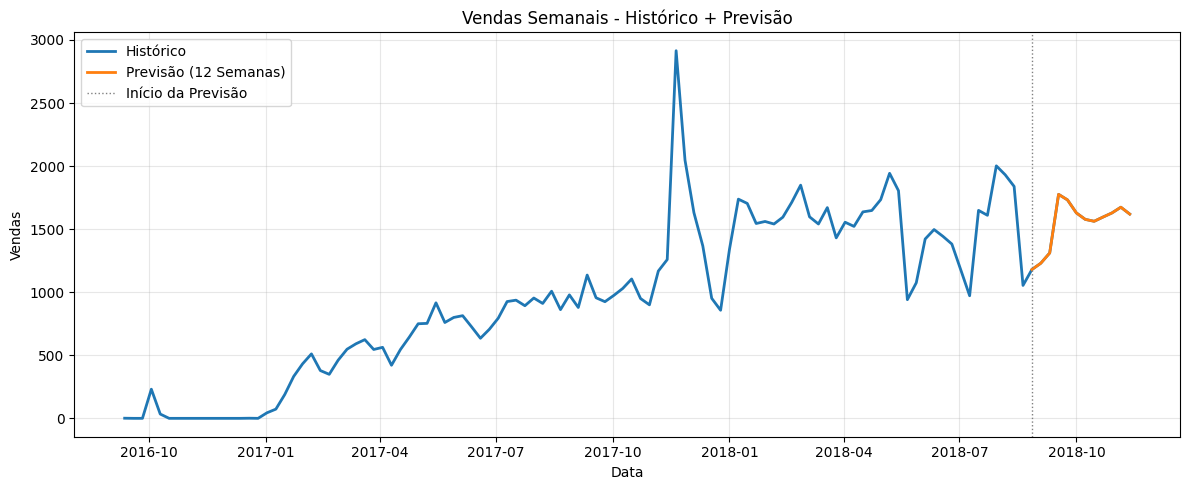

In [245]:
# Plot historical + forecast with connected lines
plt.figure(figsize=(12, 5))

# Build one connected series: historical + forecast
connected = pd.concat([weekly["sales_count"], forecast_series])

plt.plot(
    connected.index,
    connected.values,
    color="tab:blue",
    linewidth=2,
    label="Histórico",
)

# Re-plot forecast segment in a different color (keeps visual distinction)
plt.plot(
    forecast_series.index,
    forecast_series.values,
    color="tab:orange",
    linewidth=2,
    label="Previsão (12 Semanas)",
)

plt.axvline(
    x=forecast_series.index.min(),
    color="gray",
    linestyle=":",
    linewidth=1,
    label="Início da Previsão",
)

plt.title("Vendas Semanais - Histórico + Previsão")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()